In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


# Keller


In [2]:
function simulate_keller(μ, h, b, D, dt, T, x0)
    # Calculate the effective drift coefficient k_eff from the parabolic gradient
    # ∇c(x) = -2h*x / b^2
    # Drift term = μ * ∇c(x) = - (2 * μ * h / b^2) * x
    k_eff = (2 * μ * h) / (b^2)
    
    nsteps = Int(T / dt)
    x = zeros(nsteps)
    x[1] = x0
    
    for i in 2:nsteps
        ξ = randn()
        # Discrete update: x(t+dt) = x(t) + drift*dt + noise
        # Drift = -k_eff * x(t)
        x[i] = x[i-1] - k_eff * x[i-1] * dt + sqrt(2 * D * dt) * ξ
        
        # Optional: Handle boundary if distance cannot be negative
        if x[i] < 0
            x[i] = 0.0
        end
    end
    
    return x
end

simulate_keller (generic function with 1 method)

In [3]:
# Parameters
μ = 50          # Chemotactic sensitivity
h = 1.0          # Peak concentration
b = 63.25        # Width of the parabola
D = 0.18         # Diffusion coefficient
dt = 0.01        # Time step
T = 600.0         # Total time
x0 = b * 2.5       # Initial position

trajectory = simulate_keller(μ, h, b, D, dt, T, x0)

60000-element Vector{Float64}:
 158.125
 158.04076472478545
 158.02231311244236
 158.01010403044856
 157.96693404716314
 157.86387604544237
 157.7345341740019
 157.71941779609568
 157.65495423883976
 157.69701496814326
   ⋮
   0.9242222889168026
   1.1080696194672683
   1.1055825575089326
   1.1303403630604782
   1.0864815171882685
   1.1358978959503367
   1.1646796516278306
   1.0441499245148242
   1.045449305051181

In [8]:
@load "combined_dfs.jld2" combined_dfs

1-element Vector{Symbol}:
 :combined_dfs

In [9]:
df = combined_dfs[(10.0, 0.5)]

Row,step,agent,x,y
,Int64,Int64,Float64,Float64
1,1,1,0.0,0.0
2,11,1,0.0,0.0
3,21,1,0.0,0.0
4,31,1,0.0,0.0
5,41,1,0.0,0.0
6,51,1,0.0,0.0
7,61,1,0.0,0.0
8,71,1,0.0,0.0
9,81,1,0.0,0.0


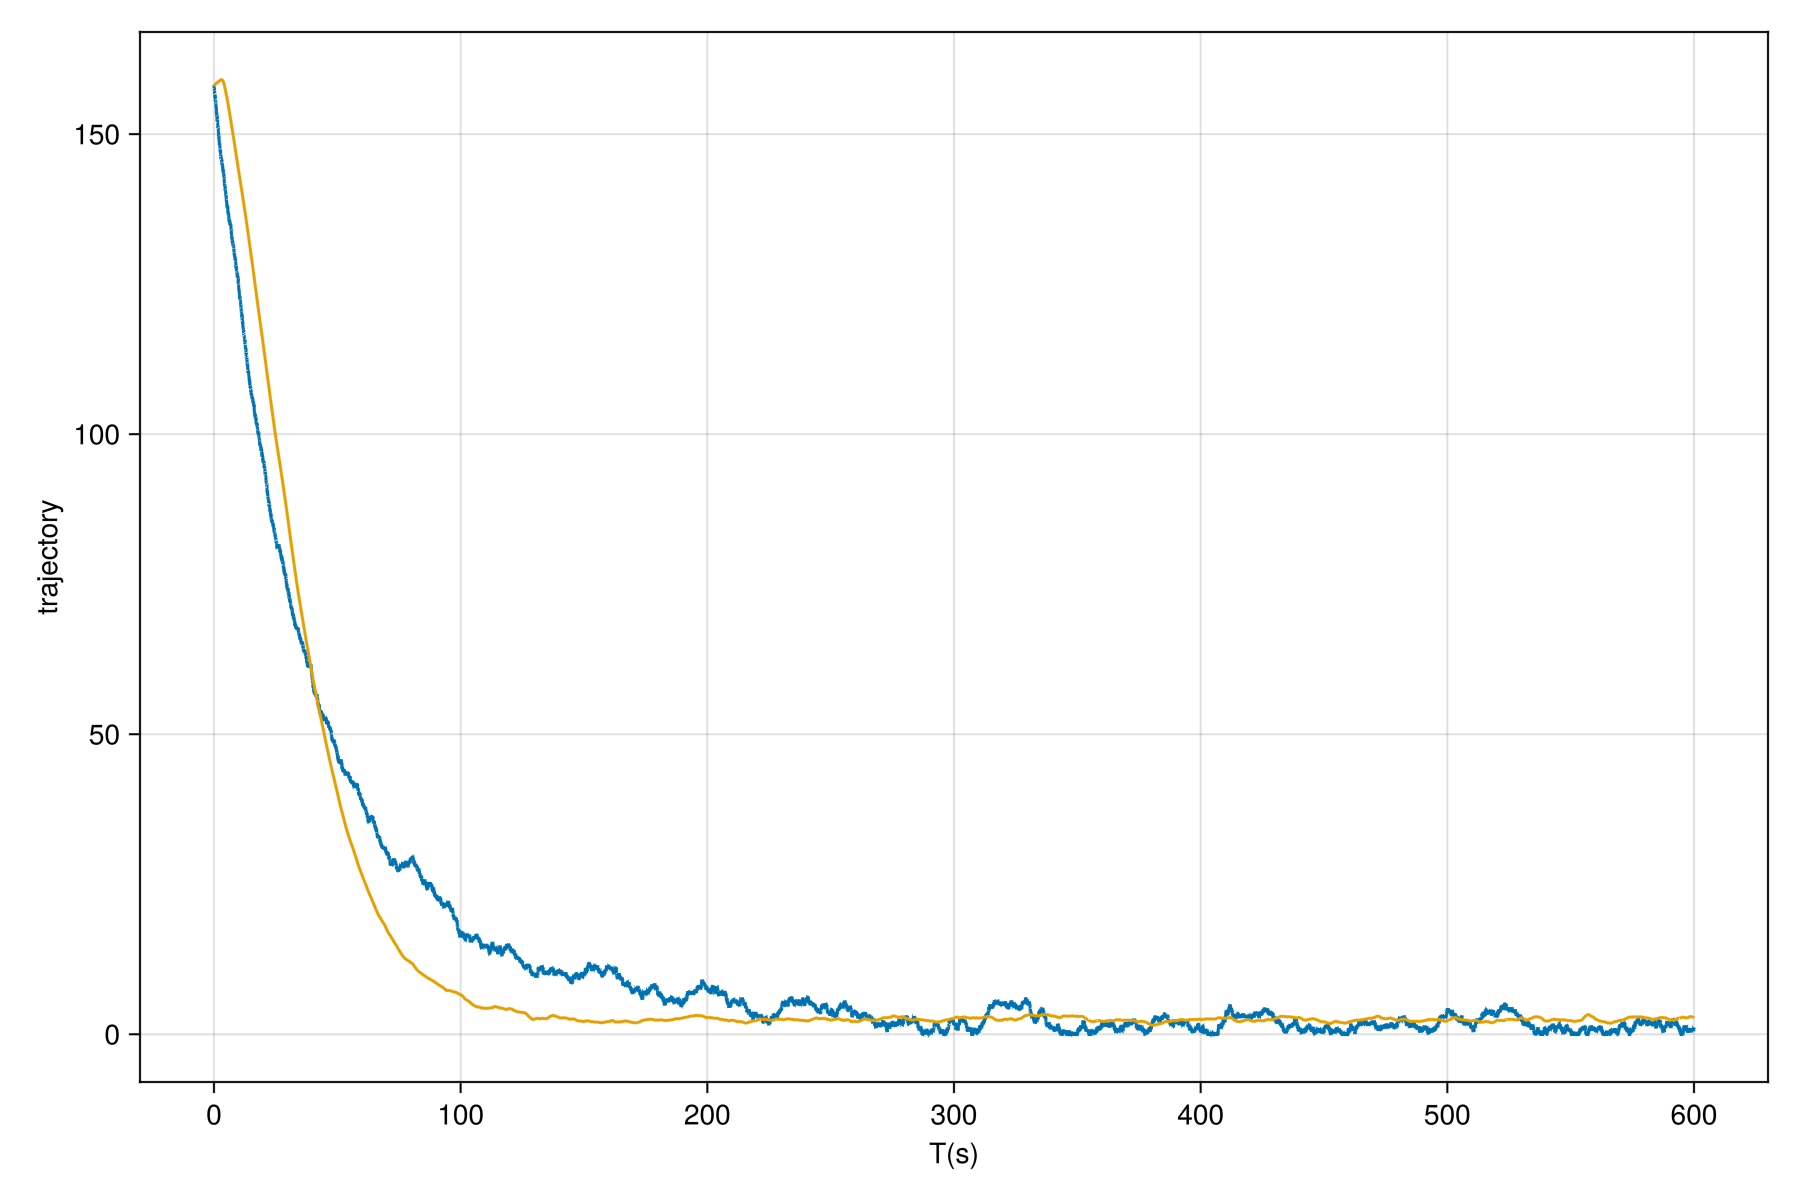

In [12]:
fig = Figure(size = (900, 600))
ax = Axis(fig[1,1], xlabel = "T(s)", ylabel = "trajectory")

steps = T / dt
grouped = groupby(df, :step)
mean_x = Float64[]
for i in 1:length(grouped)
    step_df = grouped[i]
    x = step_df.x
    push!(mean_x, mean(x))
end

steps_2 = 6000
lines!(ax, (1:steps)*0.01, trajectory)
lines!(ax, (1:steps_2)*0.1, mean_x)
fig

In [13]:
save("Plots/Fixed_source_model/keller_l05_v10_two_min.png", fig)